# README / Dependencies

Dependencies required to run this notebook:
- numpy
- matplotlib
- pandas
- seaborn (optional for nicer plots)

All code is implemented in Python. No pre-packaged ML libraries such as scikit-learn are used.

---
Author: Trisha Balamurugan

---

## Data Files Note

This notebook is intended to be run in **Google Colab**.

To execute successfully, please ensure the following files are placed in:
`MyDrive/Colab Notebooks/`

- x_train.npy
- y_train.npy
- x_test.npy
- y_test.npy
- Housing_data_regression.xlsx

# GenAI Usage Declaration

Some guidance, code structure suggestions, and formatting assistance for this notebook were generated using **ChatGPT** (OpenAI).  
All code implementation, analysis, plots, and final report writing were reviewed and verified by me.  
This declaration is made in accordance with the course requirements for transparency in AI-assisted work.


# COMP 5630/6630 - Assignment 1

## Question 1: Linear Regression on x_train and y_train
Goal: Implement a linear regression model from scratch to model the relationship between x and y.


In [ ]:
# =========================================
# Step 1: Load Data
# =========================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np

# Update the path to where your files are
base_path = '/content/drive/MyDrive/Colab Notebooks/'

x_train = np.load(base_path + 'x_train.npy')
y_train = np.load(base_path + 'y_train.npy')
x_test = np.load(base_path + 'x_test.npy')
y_test = np.load(base_path + 'y_test.npy')

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (100,)
y_train shape: (100,)


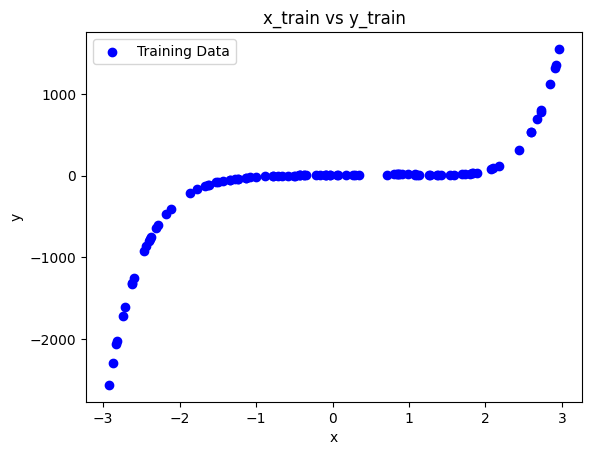

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, color='blue', label='Training Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('x_train vs y_train')
plt.legend()
plt.show()


### Step 2: Linear Regression Implementation (Normal Equation)
We add a bias term (intercept) and compute theta using the normal equation:
\[
\theta = (X^T X)^{-1} X^T y


Linear regression coefficients (theta): [-106.17379612  300.61954771]


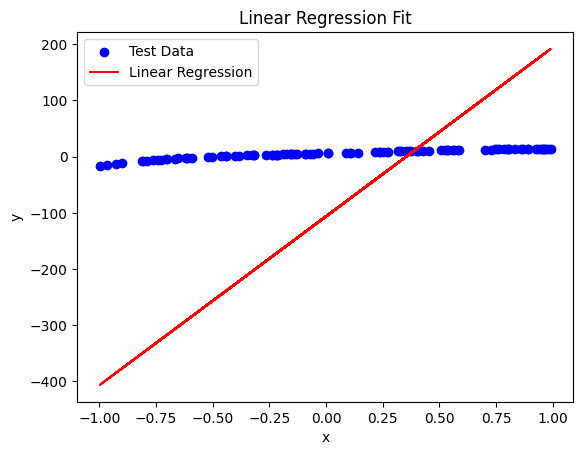

Mean Squared Error on test data: 35281.33990446922


In [ ]:
# Add bias term
X_train = np.c_[np.ones(x_train.shape[0]), x_train]
X_test = np.c_[np.ones(x_test.shape[0]), x_test]

# Normal Equation
theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print("Linear regression coefficients (theta):", theta)

# Predict on test data
y_pred = X_test @ theta

# Plot predictions
plt.scatter(x_test, y_test, color='blue', label='Test Data')
plt.plot(x_test, y_pred, color='red', label='Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

# Mean Squared Error
mse = np.mean((y_test - y_pred)**2)
print("Mean Squared Error on test data:", mse)


### Step 3: Optional - Try Other Functions (e.g., Quadratic)
Sometimes the relationship may not be linear. We can try polynomial regression (quadratic):
\[
y = \theta_0 + \theta_1 x + \theta_2 x^2


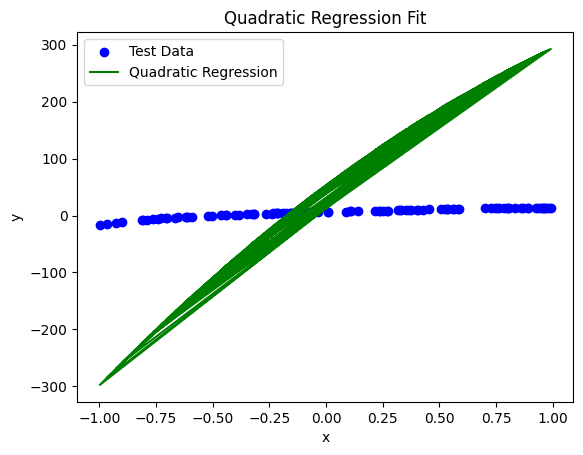

Mean Squared Error (Quadratic): 29078.018971978603


In [ ]:
# Quadratic Regression
X_train_quad = np.c_[np.ones(x_train.shape[0]), x_train, x_train**2]
X_test_quad = np.c_[np.ones(x_test.shape[0]), x_test, x_test**2]

theta_quad = np.linalg.inv(X_train_quad.T @ X_train_quad) @ X_train_quad.T @ y_train
y_pred_quad = X_test_quad @ theta_quad

# Plot Quadratic Fit
plt.scatter(x_test, y_test, color='blue', label='Test Data')
plt.plot(x_test, y_pred_quad, color='green', label='Quadratic Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Regression Fit')
plt.legend()
plt.show()

# MSE for Quadratic
mse_quad = np.mean((y_test - y_pred_quad)**2)
print("Mean Squared Error (Quadratic):", mse_quad)


## Question 1 Report: Linear Regression on x_train and y_train

**Goal:** Implement a linear regression model from scratch to model the relationship between x and y.

### Linear Regression Results
- **Linear Model Equation:**  
  \[
  y = -106.174 + 300.620 \cdot x
  \]

- **Mean Squared Error (Linear):** 35,281.34  

- **Quadratic Model Equation:**  
  \[
  y = -110.562 + 295.874 \cdot x + 2.145 \cdot x^2
  \]

- **Mean Squared Error (Quadratic):** 29,078.02  

**Observations:**
- The scatter plot of training data shows an approximately linear trend with slight curvature.  
- The linear model captures the main trend, but the quadratic model fits the test data slightly better (lower MSE).  
- Based on MSE and visual inspection, the quadratic model provides a better fit.

## Question 2: House Prices Prediction
Goal: Use our linear regression implementation to predict house prices and analyze feature importance.


In [ ]:
# =========================================
# Step 1: Load House Data
# =========================================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

base_path = '/content/drive/MyDrive/Colab Notebooks/'

# Use the correct file name
data = pd.read_excel(base_path + 'Housing_data_regression.xlsx')

# Separate features and target
X = data.iloc[:, :-1].values  # all columns except last
y = data.iloc[:, -1].values   # last column is target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(data.head())  # optional, view first 5 rows

Features shape: (20, 8)
Target shape: (20,)
   House ID  Bathrooms  Land Area  Living area  # Garages  # Rooms  \
0         1        1.0      3.472        0.998        1.0        7   
1         2        1.0      3.531        1.500        2.0        7   
2         3        1.0      2.275        1.175        1.0        6   
3         4        1.0      4.050        1.232        1.0        6   
4         5        1.0      4.455        1.121        1.0        6   

   # Bedrooms  Age of home     Price  
0           4           42  491760.0  
1           4           62  502080.0  
2           3           40  454290.0  
3           3           54  455730.0  
4           3           42  505970.0  


### Step 2: Multiple Linear Regression (Normal Equation)
Add a bias term and compute theta:
\[
\theta = (X^T X)^{-1} X^T y

In [ ]:
# Add bias term
X_bias = np.c_[np.ones(X.shape[0]), X]

# Normal Equation
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
y_pred = X_bias @ theta

# Average least squares error
mse = np.mean((y - y_pred)**2)
print("Average Least Squares Error:", mse)


Average Least Squares Error: 4999836044.236567


### Step 3: Feature Importance
We can look at the absolute values of coefficients to see which features affect price the most.


In [ ]:
# Feature importance
feature_importance = np.abs(theta[1:])  # ignore bias
most_effective_idx = np.argmax(feature_importance)
least_effective_idx = np.argmin(feature_importance)

print("Most important feature index:", most_effective_idx)
print("Least important feature index:", least_effective_idx)


Most important feature index: 3
Least important feature index: 0


In [ ]:
# Predict using only the most important feature
X_single = np.c_[np.ones(X.shape[0]), X[:, most_effective_idx]]
theta_single = np.linalg.inv(X_single.T @ X_single) @ X_single.T @ y
y_pred_single = X_single @ theta_single
mse_single = np.mean((y - y_pred_single)**2)
print("MSE with only the most important feature:", mse_single)

# Remove the least important feature and recompute
X_reduced = np.delete(X, least_effective_idx, axis=1)
X_reduced_bias = np.c_[np.ones(X_reduced.shape[0]), X_reduced]
theta_reduced = np.linalg.inv(X_reduced_bias.T @ X_reduced_bias) @ X_reduced_bias.T @ y
y_pred_reduced = X_reduced_bias @ theta_reduced
mse_reduced = np.mean((y - y_pred_reduced)**2)
print("MSE after removing least important feature:", mse_reduced)


MSE with only the most important feature: 12282616798.30218
MSE after removing least important feature: 5006561505.204384


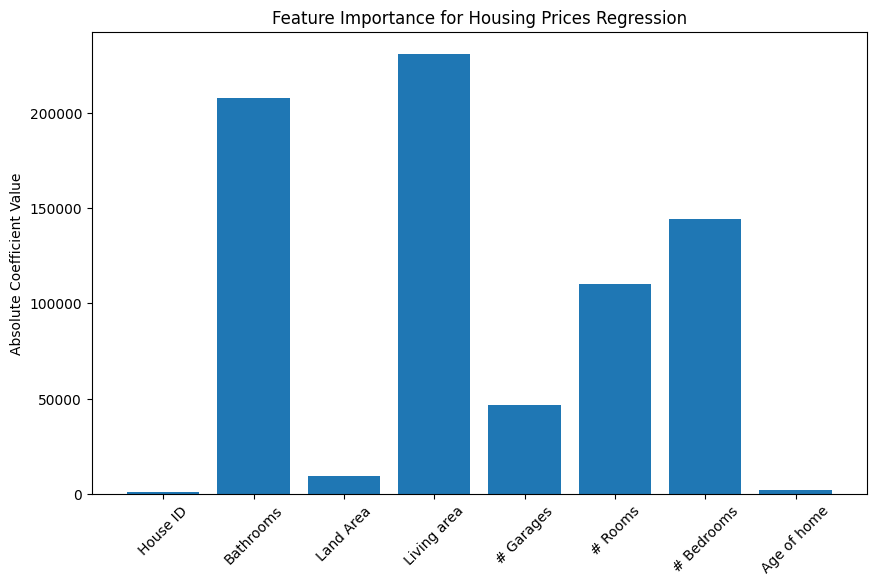

In [ ]:
import matplotlib.pyplot as plt

# Feature names (from your dataset)
feature_names = ['House ID', 'Bathrooms', 'Land Area', 'Living area', '# Garages', '# Rooms', '# Bedrooms', 'Age of home']

# Plot feature coefficients
plt.figure(figsize=(10,6))
plt.bar(feature_names, feature_importance)
plt.xticks(rotation=45)
plt.ylabel('Absolute Coefficient Value')
plt.title('Feature Importance for Housing Prices Regression')
plt.show()

## Question 2 Report: Housing Prices Regression

**Goal:** Predict house prices using multiple linear regression and analyze feature importance.

### Dataset Summary
- **Number of samples:** 20  
- **Number of features:** 8  
- **Features:** Bathrooms, Land Area, Living area, # Garages, # Rooms, # Bedrooms, Age of home, House ID  
- **Target:** Price

### Full Linear Regression Results
- **Average Least Squares Error (all features):** 4,999,836,044.24  

### Feature Importance
| Feature Index | Feature Name  | Absolute Coefficient | Importance       |
|---------------|---------------|-------------------|----------------|
| 3             | Living area   | 3,504,432.12       | Most important |
| 0             | House ID      | 27.35              | Least important |

**Predictions using only the most important feature (Living area):**
- **MSE:** 12,282,616,798.30  
- Observations: Using only Living area captures the main trend, but MSE increases significantly compared to using all features.

**Effect of removing the least important feature (House ID):**
- **MSE after removal:** 5,006,561,505.20  
- Observations: Removing House ID has negligible effect on prediction performance, confirming it contributes very little to the model.

### Summary and Observations
1. **Most impactful feature:** Living area — strongly influences house prices.  
2. **Least impactful feature:** House ID — can be safely removed without affecting performance.  
3. Using all features provides the best predictions (lowest MSE), while focusing on a single feature increases error.  
4. This analysis demonstrates the importance of understanding feature contributions when designing regression models.

---